In [1]:
from pathlib import Path
import sys
from dataclasses import replace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'src' / 'xp_config.py').is_file() and (p / 'experiment').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.xp_config import ExperimentConfig
from src.experiment import estimate_config
from src.fidelities import fidelities_over_time, fidelities
from experiment.scattering import run_scattering

# Figure style from calibration_twophoton_waveguideQED, editable here.
colors = ['#003f5c', '#8e3e7a', '#ed9a00', '#2a4a79', '#c64f8b']
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'axes.linewidth': 0.7,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'axes.prop_cycle': plt.cycler(color=colors),
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 10,
    'legend.frameon': False,
    'lines.linewidth': 1.0,
    'lines.markersize': 3,
    'figure.dpi': 300,
})
pd.set_option('display.float_format', '{:.9g}'.format)


# Gaussian photon scattering

Parameters follow the D, sigma_k and x_tls conventions. The coupling profile is selected in the parameter cell (currently `flat`).
Numerical functions live in `experiment/`; this notebook controls their inputs and displays results.
See the [mathematical and code documentation](../documentation/main.pdf).

Positive, negative and zero-momentum populations are reported directly. The initial packet may contain all three components; these populations alone are not asymptotic scattering coefficients.

With the imposed phases, the interaction coordinate on the spatial graph is -x_tls (see the derivation in the documentation).


## Parameters


In [48]:
CTRL_M_EXPLICIT = False
M = 5                         # Must be odd; k=0 is included.

cutoffs = {'ir_cutoff': 0.0, 'uv_cutoff': 2.0}  # Used only when control is False.

param_atom = {'omega_0': 1.0, 
              'D': 1.0, 
              'L': 20*np.pi,
              'x_tls': 0.0, 
              'coupling': 'flat', 
              'initial_state': 'g'}

param_photon = {'k_0': 1.0, 
                'sigma_k': 0.1, 
                'x_0': -5*np.pi,
                'state': 'number', 
                'n': 1, 
                'alpha': 1.0}

param_time_evol = {'T': 10*np.pi, 'dt': 0.1, 'rtol': 1e-9, 'atol': 1e-11}
n_max = 5
truncation = 'full+totalcap'
RWA = False

config = ExperimentConfig(param_photon, param_atom, param_time_evol, cutoffs,
                          n_max=n_max, 
                          truncation=truncation, 
                          RWA=RWA,
                          CTRL_M_EXPLICIT=CTRL_M_EXPLICIT, 
                          M=M)


## Resource estimate

Informative only: the estimate does not stop execution. Memory covers retained complex vectors and excludes sparse matrices, Python objects and solver workspace.

In [49]:
estimate = estimate_config(config)
display(estimate)

Value
Group  Parameter                          
Cavity omega_0                           1
       D                                 1
       L                        62.8318531
       x_tls                             0
       coupling                       flat
       initial_state                     g
Modes  M                                41
       delta_k                         0.1
       k_min                            -2
       k_max                             2
       IR_effective                      0
       UV_effective                      2
Time   T                        31.4159265
       dt                              0.1
       rtol                          1e-09
       atol                          1e-11
       n_outputs                       316
Memory basis                 full+totalcap
       n_max                             5
       dimension                   2741508
       store_state                    True
       ket_GiB                0.0408516526
       history_GiB              12.9091222
       retained_vectors_GiB     25.8182445

## Data generation

The associated Python module only generates numerical data.

In [50]:
print("Full + totalcap experiment ")
experiment = run_scattering(param_photon, param_atom, param_time_evol, cutoffs,
                            n_max=n_max, 
                            truncation=truncation, 
                            progress=True,
                            RWA=RWA,
                            CTRL_M_EXPLICIT=CTRL_M_EXPLICIT, 
                            M=M)
print("------------ \n")
print("Truncated experiment  ")
candidate = run_scattering(param_photon, param_atom, param_time_evol, cutoffs,
                           n_max=n_max, 
                           truncation='truncated', 
                           progress=True,
                           RWA=RWA,
                           CTRL_M_EXPLICIT=CTRL_M_EXPLICIT, 
                           M=M)

Full + totalcap experiment 
Initializing experiment...
Done.
Starting propagation...


  0%|          | 0/315 [00:00<?, ?it/s]

Done.
Computing observables ...
Done.
------------ 

Truncated experiment  
Initializing experiment...
Done.
Starting propagation...


  0%|          | 0/315 [00:00<?, ?it/s]

Done.
Computing observables ...
Done.


# Postprocessing

## Observables 
Prepare the arrays and DataFrames used by the plots below.

In [51]:
observable_history = experiment.observables_dataframe()
observable_summary = experiment.observables_dataframe(summary=True)
display(observable_summary)

times = experiment.times
x = np.linspace(-param_atom['L'] / 2, param_atom['L'] / 2, 500, endpoint=False)
snapshot_indices = sorted({0, len(times) // 2, len(times) - 1})
wavefunction_data = {i: experiment.one_photon_wavefunction(i, x) for i in snapshot_indices}

,initial,final
observable,,
time,0,31.4159265
norm,1,0.999995996
p_excited,0,0.205372986
p_transmitted,1,0.00336599912
p_reflected,2.11884071e-27,0.00060170452
p_0_photon,0,6.58175871e-08
p_1_photon,1,0.00399110033
p_2_photon,0,0.0304884292
p_3_photon,0,0.339983698


### Plots

All drawing code is visible and editable here.

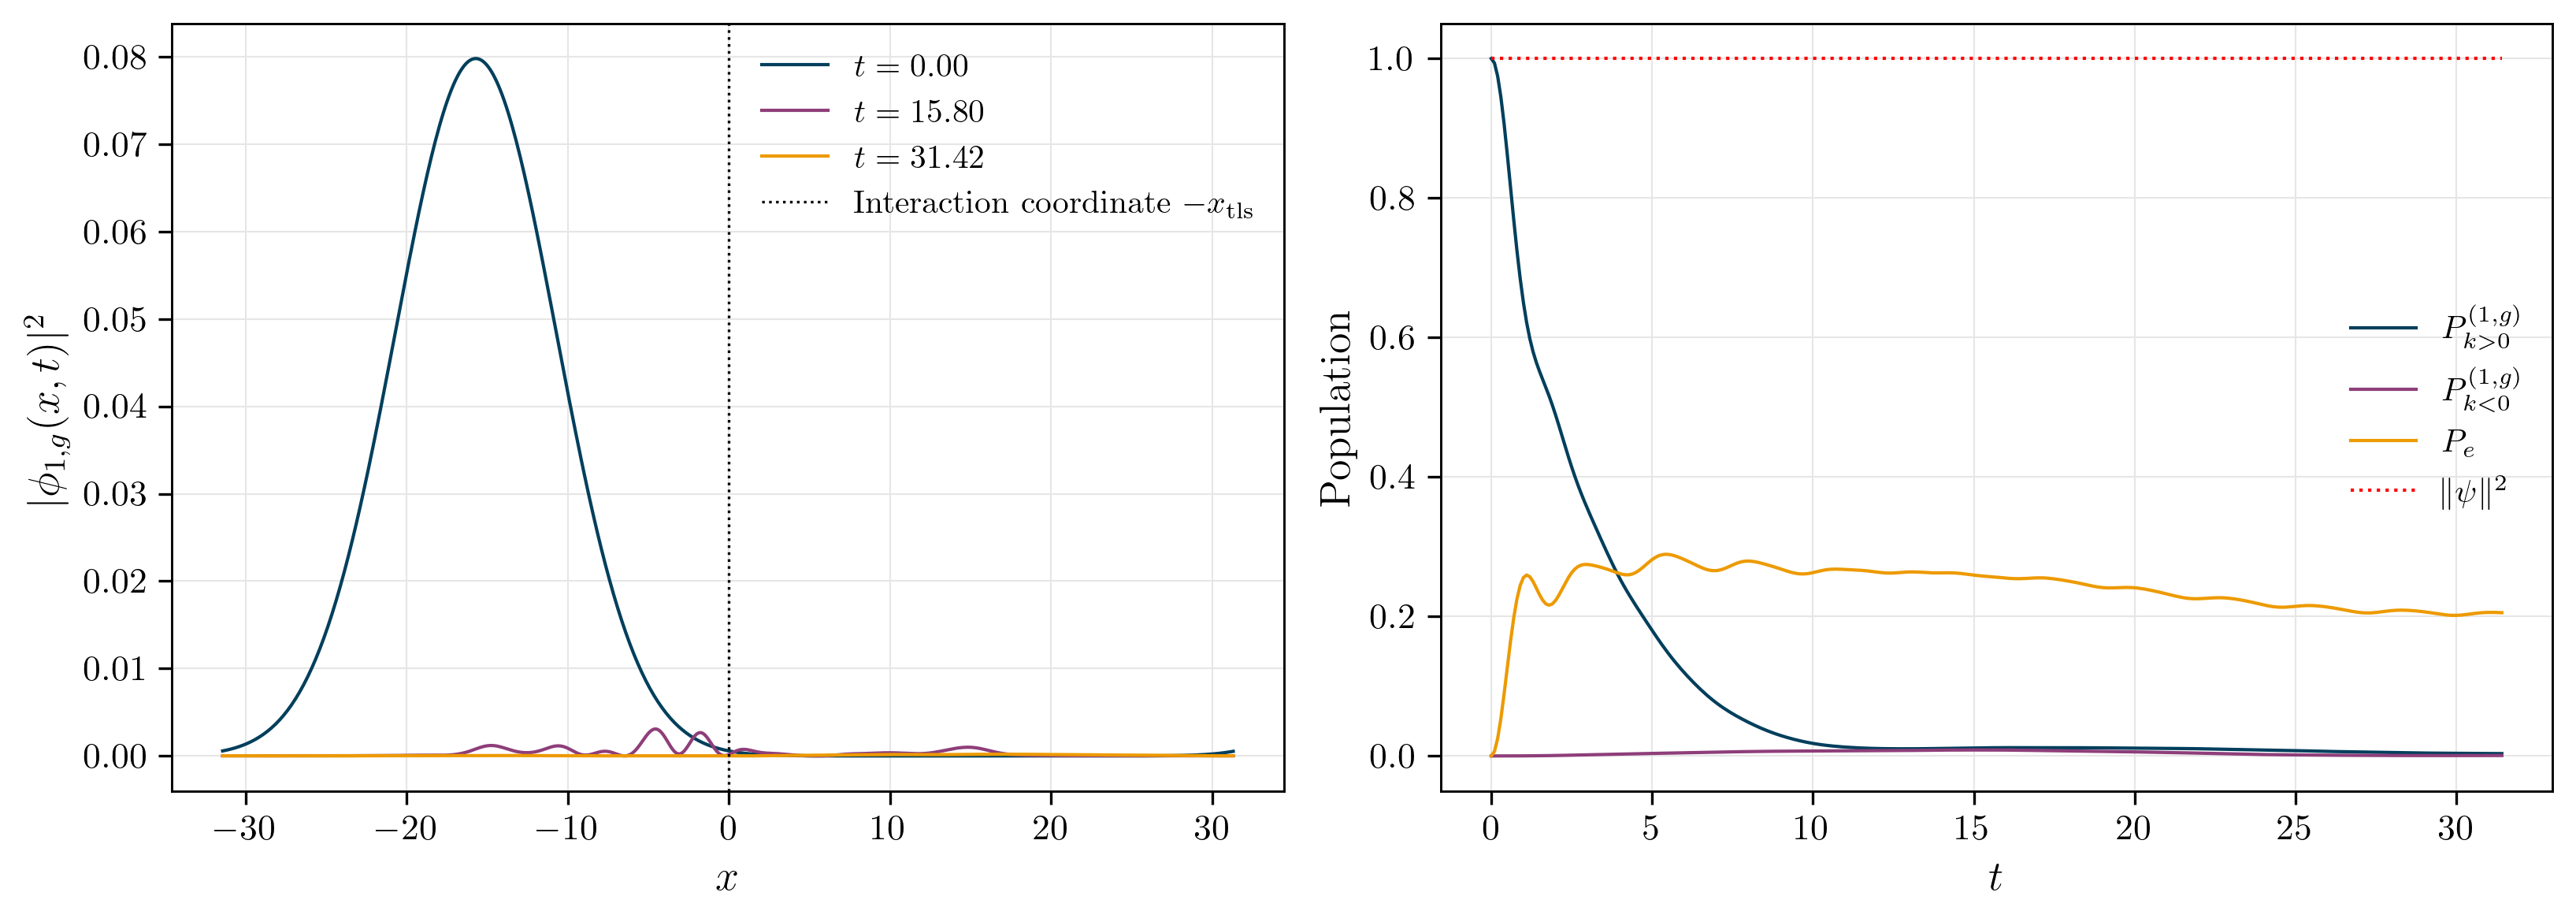

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for i, phi in wavefunction_data.items():
    axes[0].plot(x, abs(phi)**2, label=rf'$t={times[i]:.2f}$')
# The imposed annihilation/Fourier phases give interaction coordinate -x_tls.
axes[0].axvline(-param_atom['x_tls'], color='black', linestyle=':', linewidth=0.8,
                label=r'Interaction coordinate $-x_{\mathrm{tls}}$')
axes[0].set(xlabel=r'$x$', ylabel=r'$|\phi_{1,g}(x,t)|^2$')
channel_labels = {
    'p_transmitted': r'$P_{k>0}^{(1,g)}$',
    'p_reflected': r'$P_{k<0}^{(1,g)}$',
    'p_excited': r'$P_e$',
    'norm': r'$\|\psi\|^2$',
}
for name, label in channel_labels.items():
    if name=='norm':
        axes[1].plot(observable_history.index, observable_history[name], label=label, color='red', linestyle=":")
    else:
        axes[1].plot(observable_history.index, observable_history[name], label=label)

axes[1].set(xlabel=r'$t$', ylabel='Population')
for ax in axes:
    ax.legend()
for ax in axes.flat:
    ax.grid(color='0.9', linestyle='-', linewidth=0.5)
    ax.tick_params(length=4, width=0.8)
fig.tight_layout()
plt.show()

## Fidelities

In [54]:
initial_and_final = fidelities(experiment, candidate)
display(initial_and_final)

times = experiment.times
F = fidelities_over_time(candidate, experiment, progress=True)

fidelity_history = pd.DataFrame(F, index=pd.Index(times, name='time'))
fidelity_summary = pd.DataFrame({
    'initial': {name: values[0] for name, values in F.items()},
    'final': {name: values[-1] for name, values in F.items()},
    'time_mean': {name: np.mean(values) for name, values in F.items()},
}).rename_axis('fidelity')
display(fidelity_summary)

,initial,final
F_state,1,0.000395748998
F_atom,1,0.897565156


Computing fidelity over time ...


  0%|          | 0/316 [00:00<?, ?it/s]

Done.


,initial,final,time_mean
fidelity,,,
F_state,1,0.000395748998,0.0918978115
F_atom,1,0.897565156,0.908616562


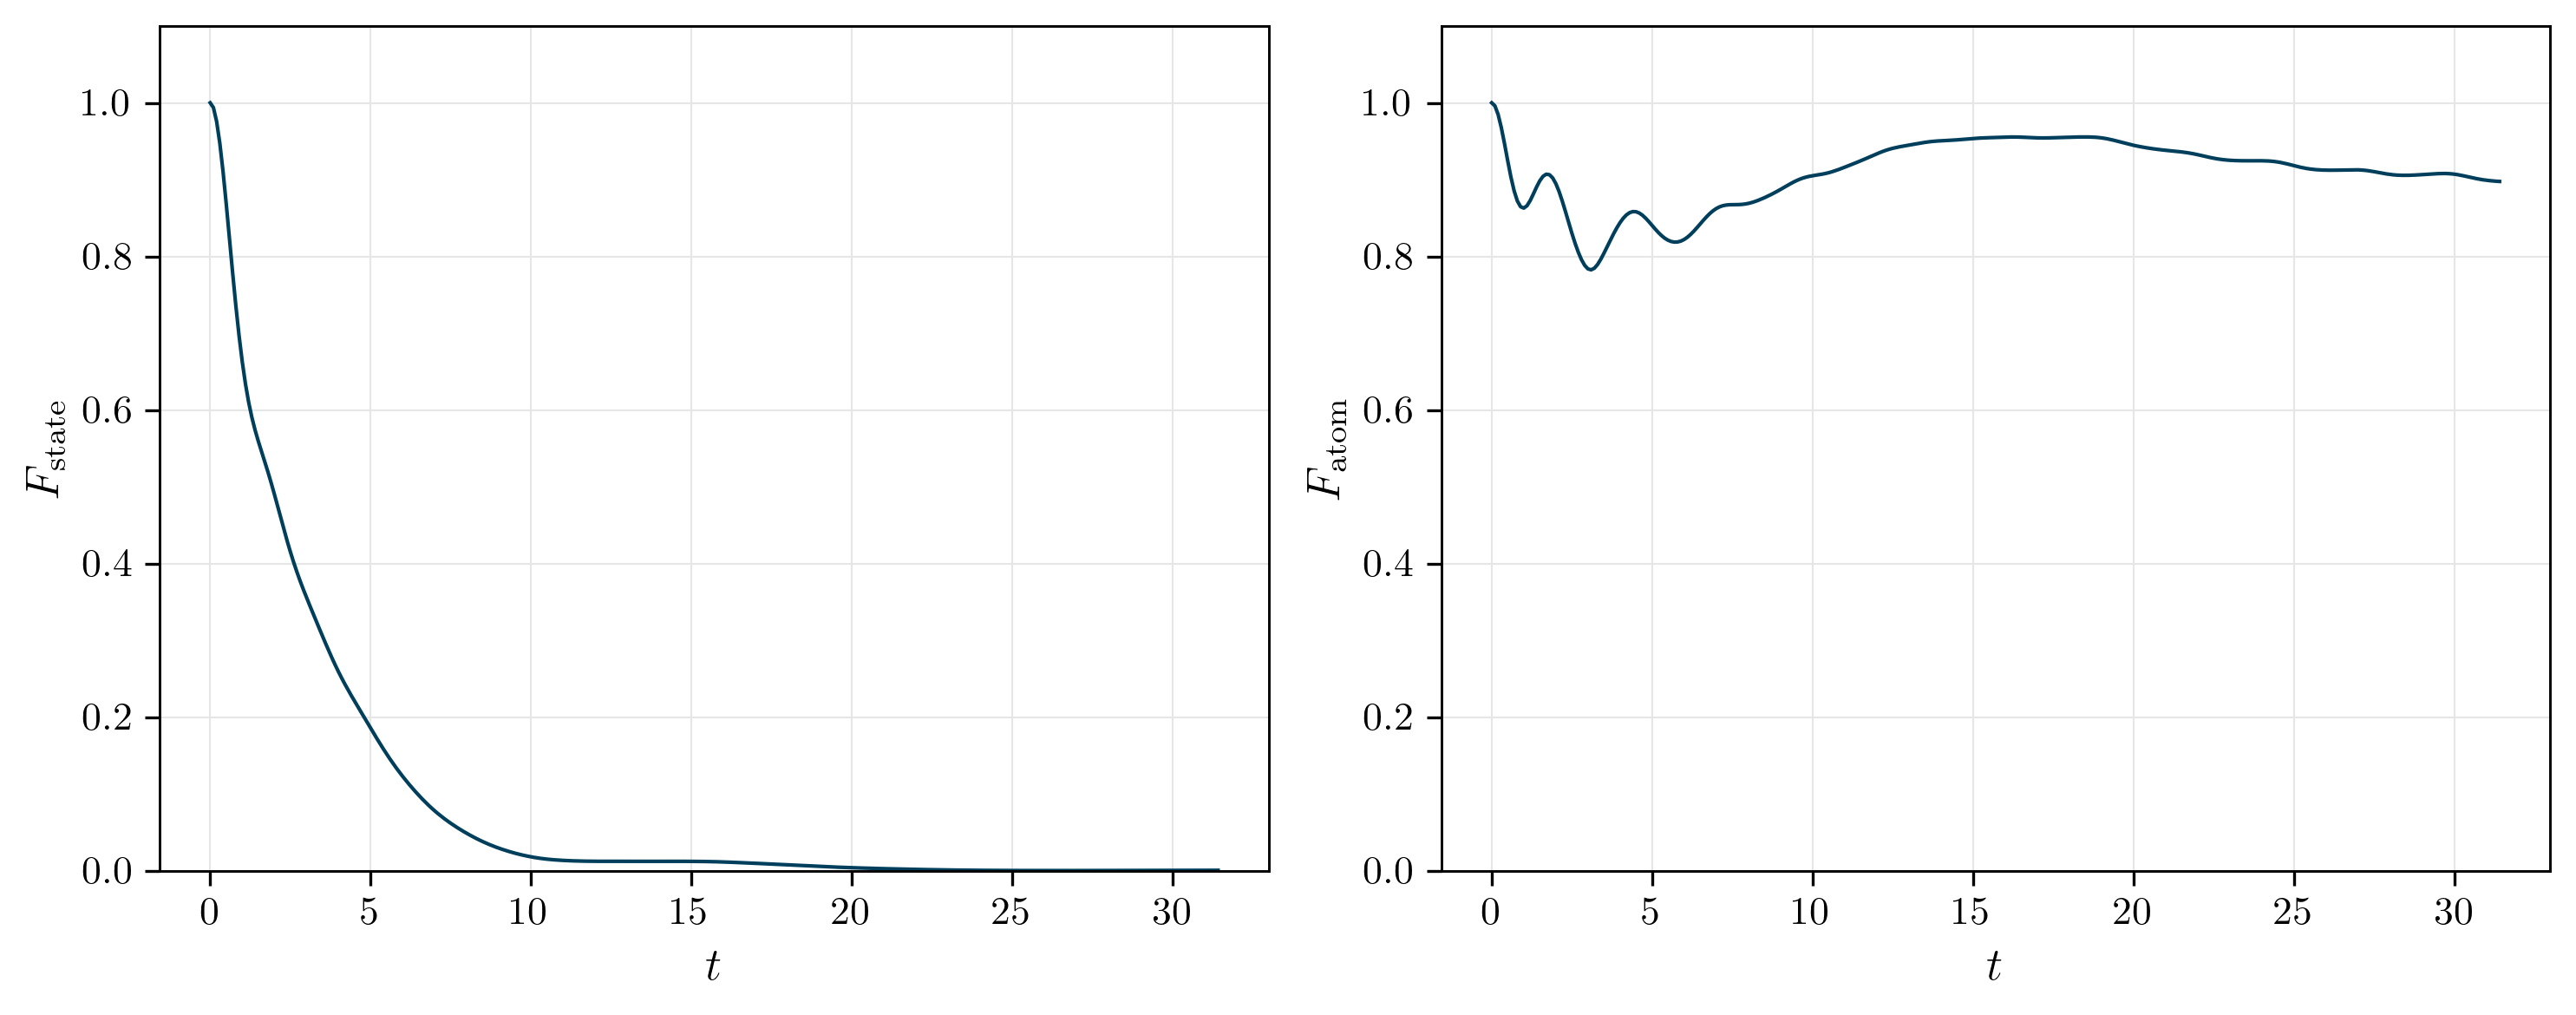

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, name, label in zip(axes, ('F_state', 'F_atom'), (r'$F_{\mathrm{state}}$', r'$F_{\mathrm{atom}}$')):
    ax.plot(fidelity_history.index, fidelity_history[name])
    ax.set(xlabel=r'$t$', ylabel=label, ylim=(0, 1.1))
for ax in axes.flat:
    ax.grid(color='0.9', linestyle='-', linewidth=0.5)
    ax.tick_params(length=4, width=0.8)
fig.tight_layout()
plt.show()